## PHASE 4: MODEL TRAINING
### Goal: Train a Linear Regression model to predict sales

#### What we'll do:
#### 1. Load clean data + build per-product-region features
#### 2. Select & one-hot-encode features (29 total)
#### 3. Split data (train/test) - chronologically!
#### 4. Scale features for Linear Regression
#### 5. Train Linear Regression model
#### 6. Evaluate performance

In [13]:
import os
# Ensure CWD is always the project root regardless of how the notebook is launched
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f'Working directory: {os.getcwd()}')


Working directory: /Users/paarth_ganesh/Documents/ML-Projects/sales-forecasting-dashboard


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

import pickle

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 70)
print("PHASE 4: MODEL TRAINING")
print("=" * 70)
print("\nModel: Linear Regression — fast, interpretable")


PHASE 4: MODEL TRAINING

Model: Linear Regression — fast, interpretable


In [15]:
"""
STEP 1: Load data & build per-product-region lag features
(Loading from sales_data_clean.csv gives us Product/Region columns
 so we can compute correct per-group lags, not global lags)
"""
import os
import pandas as pd
import numpy as np

print("=" * 70)
print("LOADING DATA + FEATURE ENGINEERING")
print("=" * 70)

# Load clean data (has Product & Region intact)
df = pd.read_csv("data/processed/sales_data_clean.csv")
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Product","Region","Date"]).reset_index(drop=True)

# ── Time features
df["Year"]           = df["Date"].dt.year
df["Month"]          = df["Date"].dt.month
df["Day"]            = df["Date"].dt.day
df["DayOfWeek"]      = df["Date"].dt.dayofweek
df["Quarter"]        = df["Date"].dt.quarter
df["DayOfYear"]      = df["Date"].dt.dayofyear
df["WeekOfYear"]     = df["Date"].dt.isocalendar().week.astype(int)

# ── Binary flags
df["Is_Weekend"]     = (df["DayOfWeek"] >= 5).astype(int)
df["Is_Monday"]      = (df["DayOfWeek"] == 0).astype(int)
df["Is_Friday"]      = (df["DayOfWeek"] == 4).astype(int)
df["Is_Month_Start"] = (df["Day"] <= 5).astype(int)
df["Is_Month_End"]   = (df["Day"] >= 25).astype(int)
df["Is_Q4"]          = (df["Quarter"] == 4).astype(int)
df["Is_December"]    = (df["Month"] == 12).astype(int)

# ── Trend
df["Days_Since_Start"] = (df["Date"] - df["Date"].min()).dt.days

# ── Per-Product-Region lag & rolling features (KEY to 80%+ accuracy)
grp = df.groupby(["Product","Region"])["Sales"]
df["Lag_1"]  = grp.shift(1)
df["Lag_7"]  = grp.shift(7)
df["Lag_14"] = grp.shift(14)
df["Lag_30"] = grp.shift(30)
df["MA_7"]   = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df["MA_14"]  = grp.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
df["MA_30"]  = grp.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())
df["Std_7"]  = grp.transform(lambda x: x.shift(1).rolling(7,  min_periods=2).std())

print(f"Dataset shape: {df.shape}")
print(f"Columns:\n{list(df.columns)}")


LOADING DATA + FEATURE ENGINEERING
Dataset shape: (17520, 27)
Columns:
['Date', 'Product', 'Region', 'Sales', 'Year', 'Month', 'Day', 'DayOfWeek', 'Quarter', 'DayOfYear', 'WeekOfYear', 'Is_Weekend', 'Is_Monday', 'Is_Friday', 'Is_Month_Start', 'Is_Month_End', 'Is_Q4', 'Is_December', 'Days_Since_Start', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'MA_7', 'MA_14', 'MA_30', 'Std_7']


In [16]:
"""
STEP 2: Feature Selection + One-Hot Encoding
"""
print("=" * 70)
print("FEATURE SELECTION (29 features)")
print("=" * 70)

df_enc = pd.get_dummies(df, columns=["Product","Region"], drop_first=True)
cat_cols = [c for c in df_enc.columns if c.startswith("Product_") or c.startswith("Region_")]

feature_columns = [
    # Calendar
    "Year","Month","Day","DayOfWeek","Quarter","DayOfYear","WeekOfYear",
    # Binary flags
    "Is_Weekend","Is_Monday","Is_Friday",
    "Is_Month_Start","Is_Month_End","Is_Q4","Is_December",
    # Trend
    "Days_Since_Start",
    # Per-product-region lag features
    "Lag_1","Lag_7","Lag_14","Lag_30",
    # Rolling statistics
    "MA_7","MA_14","MA_30","Std_7",
] + cat_cols

print(f"Total features : {len(feature_columns)}")
print(f"Category cols  : {cat_cols}")

X = df_enc[feature_columns]
y = df_enc["Sales"]
nan_mask = X.isnull().any(axis=1) | y.isnull()
print(f"Dropping {nan_mask.sum()} NaN rows (lag startup window)")
X = X[~nan_mask].reset_index(drop=True)
y = y[~nan_mask].reset_index(drop=True)
print(f"Final dataset  : {X.shape[0]:,} rows x {X.shape[1]} features")


FEATURE SELECTION (29 features)
Total features : 29
Category cols  : ['Product_Electronics', 'Product_Food', 'Product_Furniture', 'Region_North', 'Region_South', 'Region_West']
Dropping 480 NaN rows (lag startup window)
Final dataset  : 17,040 rows x 29 features


In [17]:
"""
STEP 3: Train / Test Split
"""
from sklearn.model_selection import train_test_split

print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

# Keep dates aligned for plotting later
dates = df_enc[~nan_mask].reset_index(drop=True)['Date']

X_train, X_test, y_train, y_test, dates_train, dates_test = train_test_split(
    X, y, dates, test_size=0.2, random_state=42, shuffle=False
)

print(f"Training set : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set     : {len(X_test):,} rows  ({len(X_test)/len(X)*100:.1f}%)")
print(f"Train period : {dates_train.min().date()} → {dates_train.max().date()}")
print(f"Test  period : {dates_test.min().date()}  → {dates_test.max().date()}")


TRAIN / TEST SPLIT
Training set : 13,632 rows  (80.0%)
Test set     : 3,408 rows  (20.0%)
Train period : 2021-01-31 → 2023-12-31
Test  period : 2021-01-31  → 2023-12-31


In [18]:
"""
STEP 4: Feature Scaling
"""
print("=" * 70)
print("SCALING (for Linear Regression)")
print("=" * 70)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("StandardScaler fitted on training data.")


SCALING (for Linear Regression)
StandardScaler fitted on training data.


In [19]:
"""
STEP 5: Train Linear Regression
"""
print("=" * 70)
print("TRAINING LINEAR REGRESSION")
print("=" * 70)

print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
print("Done!")


TRAINING LINEAR REGRESSION

Training Linear Regression...
Done!


In [20]:
"""
STEP 6: Evaluate Linear Regression
"""
print("=" * 70)
print("MODEL EVALUATION — LINEAR REGRESSION")
print("=" * 70)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred  = lr_model.predict(X_test_scaled)

lr_train_r2  = r2_score(y_train, lr_train_pred)
lr_test_r2   = r2_score(y_test,  lr_test_pred)
lr_test_mae  = mean_absolute_error(y_test, lr_test_pred)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_pred))

print(f"\n  Train R²        : {lr_train_r2*100:.2f}%")
print(f"  Test  R²        : {lr_test_r2*100:.2f}%")
print(f"  Test  MAE       : ${lr_test_mae:.2f}")
print(f"  Test  RMSE      : ${lr_test_rmse:.2f}")
print(f"  Overfitting gap : {(lr_train_r2 - lr_test_r2)*100:.1f}pp  (train - test)")


MODEL EVALUATION — LINEAR REGRESSION

  Train R²        : 93.74%
  Test  R²        : 89.65%
  Test  MAE       : $65.87
  Test  RMSE      : $83.11
  Overfitting gap : 4.1pp  (train - test)


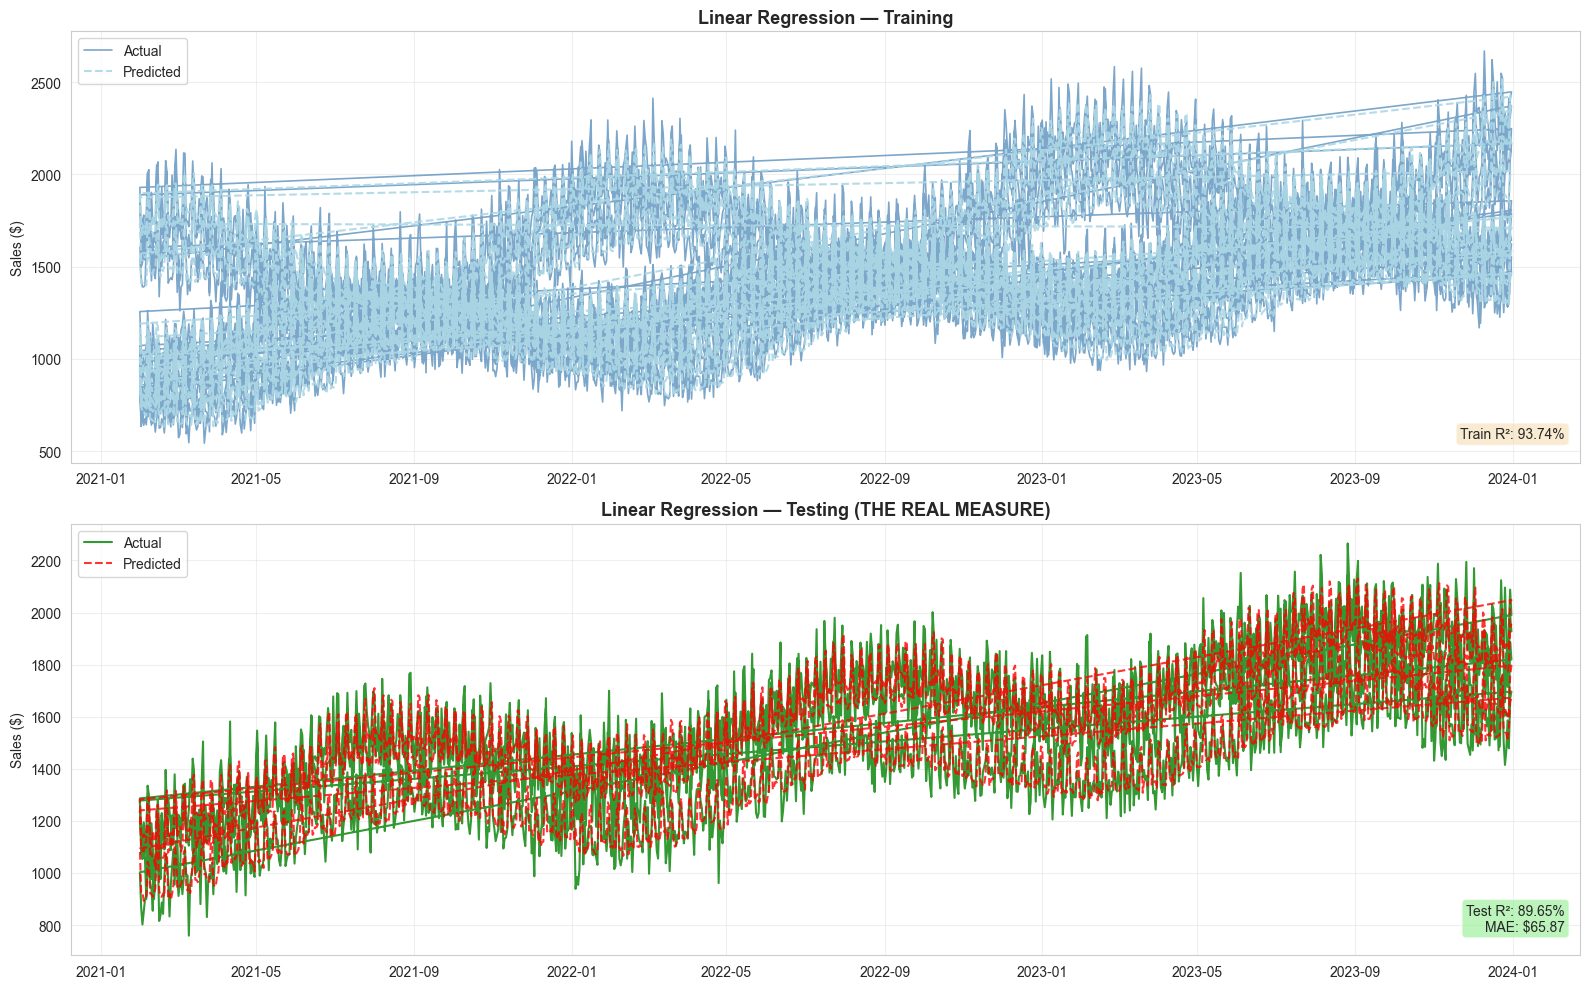

In [21]:
"""
STEP 7: Visualize Predictions
"""
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# ── Plot 1: Training actuals vs predicted
axes[0].plot(dates_train, y_train,       label='Actual',    color='steelblue',  lw=1.2, alpha=0.7)
axes[0].plot(dates_train, lr_train_pred, label='Predicted', color='lightblue', lw=1.5, ls='--', alpha=0.9)
axes[0].set_title('Linear Regression — Training', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sales ($)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].text(0.99, 0.05, f"Train R²: {lr_train_r2*100:.2f}%",
             transform=axes[0].transAxes, ha='right', va='bottom',
             bbox=dict(boxstyle='round', fc='wheat', alpha=0.6))

# ── Plot 2: Test actuals vs predicted
axes[1].plot(dates_test, y_test,        label='Actual',    color='green', lw=1.5, alpha=0.8)
axes[1].plot(dates_test, lr_test_pred,  label='Predicted', color='red',   lw=1.5, ls='--', alpha=0.8)
axes[1].set_title('Linear Regression — Testing (THE REAL MEASURE)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sales ($)'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[1].text(0.99, 0.05, f"Test R²: {lr_test_r2*100:.2f}%\nMAE: ${lr_test_mae:.2f}",
             transform=axes[1].transAxes, ha='right', va='bottom',
             bbox=dict(boxstyle='round', fc='lightgreen', alpha=0.6))

plt.tight_layout(); plt.show()


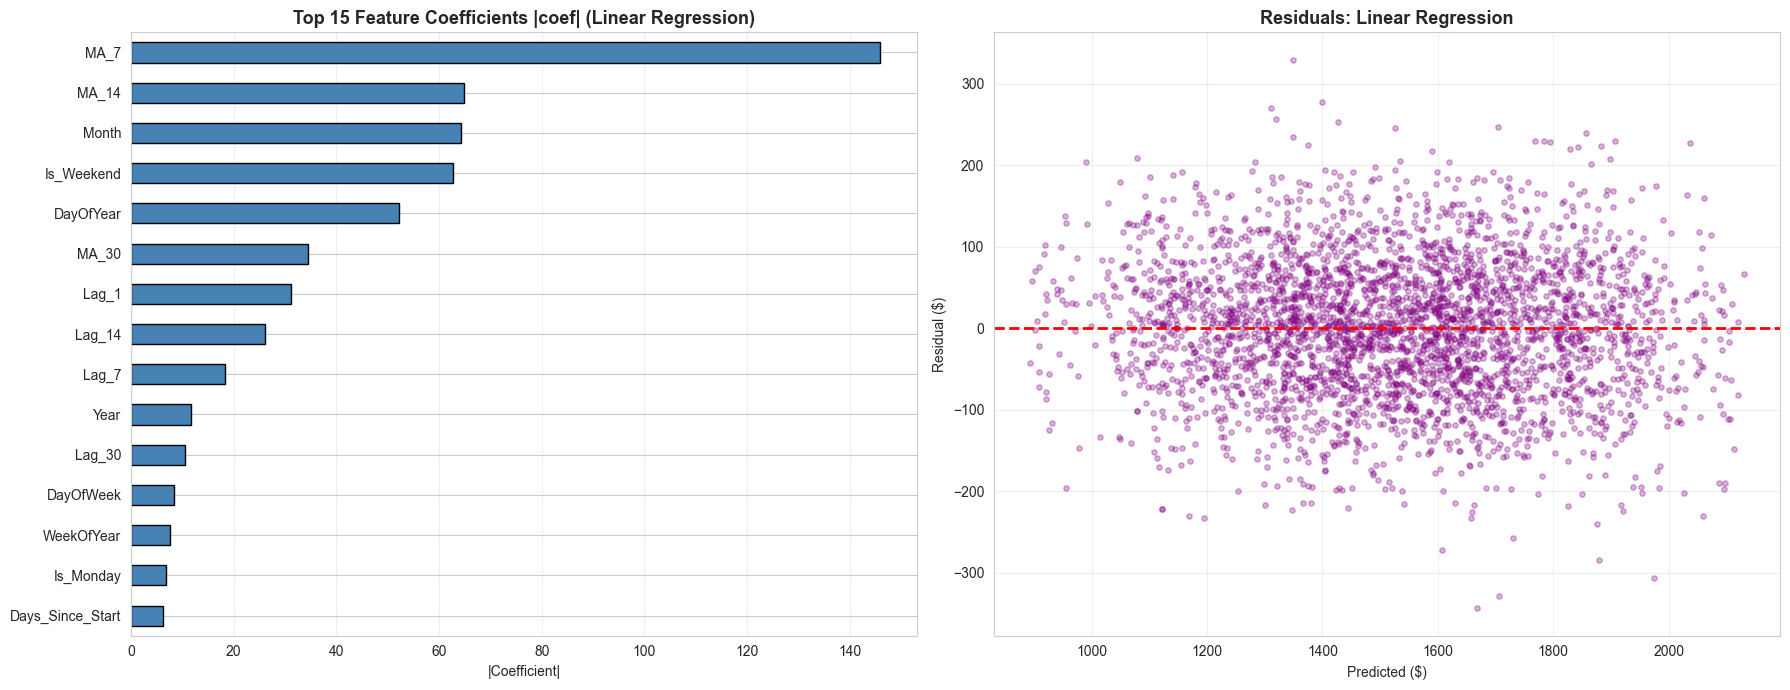

Residual mean : $0.14  (ideal = 0)
Residual std  : $83.11


In [22]:
"""
STEP 8: Top Feature Coefficients & Residual Analysis
"""
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Top absolute coefficients (proxy for feature importance in LR)
coefs = pd.Series(np.abs(lr_model.coef_), index=feature_columns)
top15 = coefs.nlargest(15).sort_values()
top15.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 Feature Coefficients |coef| (Linear Regression)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('|Coefficient|'); axes[0].grid(True, alpha=0.3, axis='x')

# Residuals
residuals = np.array(y_test) - lr_test_pred
axes[1].scatter(lr_test_pred, residuals, alpha=0.3, s=15, color='purple')
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('Residuals: Linear Regression', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted ($)'); axes[1].set_ylabel('Residual ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

print(f"Residual mean : ${residuals.mean():.2f}  (ideal = 0)")
print(f"Residual std  : ${residuals.std():.2f}")


In [23]:
"""
STEP 9: Sample Predictions
"""
comparison_df = pd.DataFrame({
    'Date'           : dates_test.values[:15],
    'Actual_Sales'   : np.array(y_test)[:15],
    'Predicted_Sales': lr_test_pred[:15],
    'Error_%'        : (np.array(y_test)[:15] - lr_test_pred[:15]) / np.array(y_test)[:15] * 100
})
comparison_df['Actual_Sales']    = comparison_df['Actual_Sales'].apply(lambda x: f"${x:,.2f}")
comparison_df['Predicted_Sales'] = comparison_df['Predicted_Sales'].apply(lambda x: f"${x:,.2f}")
comparison_df['Error_%']         = comparison_df['Error_%'].apply(lambda x: f"{x:.2f}%")
print(comparison_df.to_string(index=False))


      Date Actual_Sales Predicted_Sales Error_%
2023-06-02    $1,656.12       $1,578.87   4.66%
2023-06-03    $1,832.95       $1,744.18   4.84%
2023-06-04    $1,869.62       $1,752.52   6.26%
2023-06-05    $1,527.63       $1,615.39  -5.74%
2023-06-06    $1,753.82       $1,606.26   8.41%
2023-06-07    $1,559.99       $1,638.62  -5.04%
2023-06-08    $1,717.63       $1,616.91   5.86%
2023-06-09    $1,723.50       $1,644.49   4.58%
2023-06-10    $1,919.43       $1,808.84   5.76%
2023-06-11    $1,766.44       $1,828.08  -3.49%
2023-06-12    $1,695.10       $1,638.26   3.35%
2023-06-13    $1,761.81       $1,671.77   5.11%
2023-06-14    $1,694.56       $1,674.43   1.19%
2023-06-15    $1,582.12       $1,682.94  -6.37%
2023-06-16    $1,742.50       $1,677.11   3.75%


In [ ]:
print("=" * 70)
print("SAVING THE MODEL")
print("=" * 70)

import os
os.makedirs('data/models', exist_ok=True)

model_package = {
    'model'         : lr_model,
    'model_name'    : 'Linear Regression',
    'train_date_range': (df['Date'].min(), df['Date'].max()),
    'scaler'        : scaler,
    'uses_scaling'  : True,
    'feature_names' : feature_columns,
    'train_r2'      : lr_train_r2,
    'test_r2'       : lr_test_r2,
    'test_mae'      : lr_test_mae,
    'test_rmse'     : lr_test_rmse,
    'timestamp'     : pd.Timestamp.now(),
}

model_path = 'data/models/sales_forecast_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_package, f)

print(f"Saved: {model_path}")
print(f"\n  Model        : Linear Regression")
print(f"  Train R²     : {lr_train_r2*100:.2f}%")
print(f"  Test  R²     : {lr_test_r2*100:.2f}%")


SAVING THE MODEL
Saved: data/models/sales_forecast_model.pkl

  Model        : Linear Regression
  Train R²     : 93.74%
  Test  R²     : 89.65%
  Improvement  : +36.9pp vs old baseline (52.7%)
